In [2]:
# log파일 추가 시 한번만 실행
import _common
_common.read_logs()

Reading logs/Huam415-1/251016_SM-S938N_TEST06_n-M1_Fav.xlsx
Reading logs/Huam415-1/251024_SM-S938N_TEST16-M2_Fav.xlsx
Reading logs/Huam415-1/251022_SM-S938N_TEST31_-M2_Fav.xlsx
Reading logs/Huam415-1/251024_SM-S938N_TEST24-M2_Fav.xlsx
Reading logs/Huam415-1/251024_SM-S938N_TEST17-M1_Fav.xlsx
Reading logs/Huam415-1/251022_SM-S938N_TEST07_-M2_Fav.xlsx
Reading logs/Huam415-1/251016_SM-S938N_TEST02_n28-M1_Fav.xlsx
Reading logs/Huam415-1/251022_SM-S938N_TEST09_-M1_Fav.xlsx
Reading logs/Huam415-1/251022_SM-S938N_TEST30_-M2_Fav.xlsx
Reading logs/Huam415-1/251017_SM-S938N_TEST02_N26-M1_Fav.xlsx
Reading logs/Huam415-1/251022_SM-S938N_TEST13_-M2_Fav.xlsx
Reading logs/Huam415-1/251024_SM-S938N_TEST13-M2_Fav.xlsx
Reading logs/Huam415-1/251024_SM-S938N_TEST20-M1_Fav.xlsx
Reading logs/Huam415-1/251022_SM-S938N_TEST14_-M2_Fav.xlsx
Reading logs/Huam415-1/251016_SM-S938N_TEST05_n-M1_Fav.xlsx
Reading logs/Huam415-1/251022_SM-S938N_TEST01_-M2_Fav.xlsx
Reading logs/Huam415-1/251024_SM-S938N_TEST21-M2_Fav.

In [4]:
import os, _common, _map, _plot
df = _common.analyze_kpi(
    fname = os.path.join("logs",f"SM-S938N_All.xlsx"),
    date_list = [
        # "251016",
        # "251017",
        # "251020",
        # "251021",
        "251022", # pdcch dynamic 적용
        "251023",
        "251024",
        "251027",
    ],
)
out_dir = os.path.join("results", f"raw")
os.makedirs(out_dir, exist_ok=True)
_plot.plot_kpi_raw(df=df, out_dir=out_dir)

Reading logs/SM-S938N_All.xlsx
✅ Read Complete : 94800 lines
✅ Saved: results/raw/cmpr_SINR_SSB.html
✅ Saved: results/raw/cmpr_SINR_TRS.html
✅ Saved: results/raw/cmpr_RSRQ.html
✅ Saved: results/raw/cmpr_DL_Tput.html


In [1]:
import os, _common, _map, _plot
df = _common.analyze_kpi(
    fname = os.path.join("logs",f"SM-S938N_All.xlsx"),
    date_list = [
        # "251016",
        # "251017",
        # "251020",
        # "251021",
        "251022", # pdcch dynamic 적용
        "251023",
        "251024",
        "251027",
    ],
)
# grid가 커질수록 GPS 오차 보정 및 통계적 안정성 향상
# - 이동 속도 약 36 km/h (≈ 10 m/s) 기준, 30m 구간당 약 3개 샘플 수집
# - 동일 루트 10회 이상 반복 시 grid별 30개 이상 샘플 확보 가능
# - 샘플 수 30개 이상이면 중심극한정리(CLT)에 따라 정규분포 근사 가능
# - SINR, Tput 등 고분산 지표의 신뢰구간(CI) 추정에 적합

grid_size = 30
sample_min = 30
rb_min = 0

# out_dir = os.path.join("results", f"grid_{grid_size}m", "plot", "plot_group_by_site")
# os.makedirs(out_dir, exist_ok=True)
# _plot.plot_kpi_group_by_site(df=df, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min)

# out_dir = os.path.join("results", f"grid_{grid_size}m", "plot", "plot_group_by_uhd")
# os.makedirs(out_dir, exist_ok=True)
# _plot.plot_kpi_group_by_uhd(df=df, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min, band="n28")

# out_dir = os.path.join("results", f"grid_{grid_size}m", "plot")
# os.makedirs(out_dir, exist_ok=True)
# _plot.kpi_each_test(df=df, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min)

out_dir = os.path.join("results", f"grid_{grid_size}m", "map")
os.makedirs(out_dir, exist_ok=True)
df_map = df[df["route"].isin(['Namsan','Huam415-1','Huam345-5'])].copy()
_map.map_pct(df=df_map, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min)
_map.map_db(df=df_map, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min)
_map.map_coverage(df=df_map, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min, band="n28")

Reading logs/SM-S938N_All.xlsx
✅ Read Complete : 94800 lines
✅ Saved: results/grid_30m/map/cmpr_DL_Tput.html (rows=160)
✅ Saved: results/grid_30m/map/cmpr_RSRP.html (rows=160)
✅ Saved: results/grid_30m/map/n28_RSRP.html (rows=160)
✅ Saved: results/grid_30m/map/n28_SINR_TRS.html (rows=160)
✅ Saved: results/grid_30m/map/n28_DL_Tput.html (rows=160)
✅ Saved: results/grid_30m/map/n28_DL_Tput_per_RB.html (rows=160)
✅ Saved: results/grid_30m/map/n28_DL_RB.html (rows=160)


In [2]:
# grid가 작을수록 위치별 세부 경향 파악 가능하나 노이즈 및 GPS 오차 영향 증가
# - 이동 속도 약 36 km/h (≈ 10 m/s) 기준, 5m 구간당 약 0.5개 샘플 수집
# - 동일 루트를 10회 이상 반복 시, grid별로 약 5개 샘플 확보 가능
# - 샘플 수가 적어 통계적 안정성은 낮으나 세부 위치별 특성 분석에 유용
# - 미세한 신호 변동이나 국소적 간섭 분석 등에 활용 가능

grid_size = 5
sample_min = 5
rb_min = 0

# out_dir = os.path.join("results", f"grid_{grid_size}m", "plot", "plot_group_by_uhd")
# os.makedirs(out_dir, exist_ok=True)
# _plot.plot_kpi_group_by_uhd(df=df, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min, band="n28")

# out_dir = os.path.join("results", f"grid_{grid_size}m", "plot", "plot_group_by_site")
# os.makedirs(out_dir, exist_ok=True)
# _plot.plot_kpi_group_by_site(df=df, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min)

# out_dir = os.path.join("results", f"grid_{grid_size}m", "plot")
# os.makedirs(out_dir, exist_ok=True)
# _plot.kpi_each_test(df=df, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min)

out_dir = os.path.join("results", f"grid_{grid_size}m", "map")
os.makedirs(out_dir, exist_ok=True)
df_map = df[df["route"].isin(['Namsan','Huam415-1','Huam345-5'])].copy()
_map.map_coverage(df=df_map, out_dir=out_dir, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min, band="n28")

✅ Saved: results/grid_5m/map/n28_RSRP.html (rows=1449)
✅ Saved: results/grid_5m/map/n28_SINR_TRS.html (rows=1449)
✅ Saved: results/grid_5m/map/n28_DL_Tput.html (rows=1449)
✅ Saved: results/grid_5m/map/n28_DL_Tput_per_RB.html (rows=1449)
✅ Saved: results/grid_5m/map/n28_DL_RB.html (rows=1449)


In [1]:
import os, _common, _map, _plot
df = _common.analyze_kpi(
    fname = os.path.join("logs",f"SM-S938N_All.xlsx"),
    date_list = [
        # "251016",
        # "251017",
        # "251020",
        # "251021",
        "251022", # pdcch dynamic 적용
        "251023",
        "251024",
        "251027",
    ],
)

Reading logs/SM-S938N_All.xlsx
✅ Read Complete : 94800 lines


In [47]:
import numpy as np
import pandas as pd
import _common


def bin_kpi_each_band(df, band, grid_size, rb_min, sample_min, bin_size):

    # ---------------------------
    # Step 1. grid_kpi 실행
    # ---------------------------
    df_pair = _common.grid_kpi(df, grid_size=grid_size, rb_min=rb_min, sample_min=sample_min)

    # ---------------------------
    # Step 2. 밴드별 mean 컬럼 분리
    # ---------------------------
    common_cols = [c for c in df_pair.columns if not any(s in c for s in ["_n26", "_n28", "_diff"])]
    n26_cols = [c for c in df_pair.columns if c.endswith("_mean_n26")]
    n28_cols = [c for c in df_pair.columns if c.endswith("_mean_n28")]

    df_n26 = df_pair[common_cols + n26_cols].copy()
    df_n28 = df_pair[common_cols + n28_cols].copy()
    df_n26.columns = [c.replace("_mean_n26", "") for c in df_n26.columns]
    df_n28.columns = [c.replace("_mean_n28", "") for c in df_n28.columns]

    df_band = df_n26 if band == "n26" else df_n28

    # ---------------------------
    # Step 3. RSRP binning (범위 문자열로 표시)
    # ---------------------------
    rsrp_min = int(np.floor(df_band["RSRP"].min()))
    rsrp_max = int(np.ceil(df_band["RSRP"].max()))
    bins = np.arange(rsrp_min, rsrp_max + bin_size, bin_size)

    df_band["RSRP_bin"] = pd.cut(df_band["RSRP"], bins=bins, right=False)
    df_band["RSRP_bin"] = df_band["RSRP_bin"].apply(lambda x: f"[{int(x.left)}, {int(x.right)})")

    # ---------------------------
    # Step 4. KPI 컬럼 설정
    # ---------------------------
    kpi_cols=[
        "RSRP", "RSRQ", "SINR", "SINR_TRS",
        "CQI","RI","DL_MCS",
        "DL_Tput", "DL_RB",
        "DL_BLER", "UL_BLER",
    ]
    
    # ---------------------------
    # Step 5. bin별 KPI 평균 + loc_id/details 구조화
    # ---------------------------
    records = []
    grouped = df_band.groupby("RSRP_bin", observed=True)

    for bin_label, subdf in grouped:
        if subdf.empty:
            continue
        stats = {
            "RSRP_bin": bin_label,
            "count": len(subdf),
            "loc_ids": sorted(subdf["loc_id"].unique().tolist()),
            "details": subdf.apply(lambda r: r.to_dict(), axis=1).tolist()
        }
    
        kpi_means = {col: subdf[col].mean() for col in kpi_cols}
        stats.update(kpi_means)
        records.append(stats)

    df_binned = pd.DataFrame(records)
    df_binned["band"] = band

    return df_binned

In [48]:
df_n28 = bin_kpi_each_band(
    df,
    band="n28",
    grid_size=25,
    rb_min=48,
    sample_min=10,
    bin_size=1,
)

display(df_n28)

,RSRP_bin,count,loc_ids,details,RSRP,RSRQ,SINR,SINR_TRS,CQI,RI,DL_MCS,DL_Tput,DL_RB,DL_BLER,UL_BLER,band
0,"[-119, -118)",1,[177],"[{'loc_id': 177, 'lat_bin': 167221, 'lon_bin':...",-118.199286,-15.633571,-4.042857,7.591429,3.362143,1.071429,2.470714,6.073000,49.376429,8.596429,51.073571,n28
1,"[-118, -117)",4,"[185, 192, 193, 201]","[{'loc_id': 185, 'lat_bin': 167223, 'lon_bin':...",-117.452660,-15.218795,-3.147224,6.913669,3.482654,1.065007,2.537717,6.089574,49.158416,9.041744,37.420116,n28
2,"[-117, -116)",4,"[188, 196, 199, 202]","[{'loc_id': 188, 'lat_bin': 167224, 'lon_bin':...",-116.476354,-14.529451,-1.720292,7.236463,3.642621,1.034375,2.496195,6.002977,49.258757,9.251190,41.991122,n28
3,"[-116, -115)",2,"[189, 198]","[{'loc_id': 189, 'lat_bin': 167224, 'lon_bin':...",-115.594839,-14.234452,-1.444396,8.267504,4.137931,1.007246,3.432834,7.804799,49.555821,9.135242,37.605749,n28
4,"[-115, -114)",3,"[184, 206, 207]","[{'loc_id': 184, 'lat_bin': 167223, 'lon_bin':...",-114.165020,-14.595527,-1.797890,10.221075,5.368792,1.095220,4.291683,9.884495,49.563365,9.583260,22.574969,n28
5,"[-114, -113)",5,"[176, 205, 210, 211, 212]","[{'loc_id': 176, 'lat_bin': 167221, 'lon_bin':...",-113.590514,-15.063765,-3.028201,11.283498,5.352692,1.142592,4.840205,11.492175,49.688064,9.416463,20.242874,n28
6,"[-113, -112)",4,"[165, 203, 204, 213]","[{'loc_id': 165, 'lat_bin': 167219, 'lon_bin':...",-112.598304,-14.718208,-2.253400,12.814019,6.045750,1.127346,6.217585,14.148006,49.764389,9.100666,15.511747,n28
7,"[-112, -111)",3,"[169, 170, 209]","[{'loc_id': 169, 'lat_bin': 167220, 'lon_bin':...",-111.362271,-14.291438,-0.777719,11.471490,5.175535,1.000000,5.523531,11.948921,49.698514,8.992122,16.114295,n28
8,"[-111, -110)",5,"[130, 136, 164, 200, 208]","[{'loc_id': 130, 'lat_bin': 167213, 'lon_bin':...",-110.585076,-14.778042,-1.358956,13.112536,6.270970,1.045308,5.829474,12.754234,49.711676,9.355979,13.223767,n28
9,"[-110, -109)",6,"[121, 139, 140, 144, 151, 174]","[{'loc_id': 121, 'lat_bin': 167212, 'lon_bin':...",-109.415582,-15.081745,-1.724993,14.365824,6.477778,1.057678,5.752081,12.703034,49.674816,9.311234,12.468876,n28


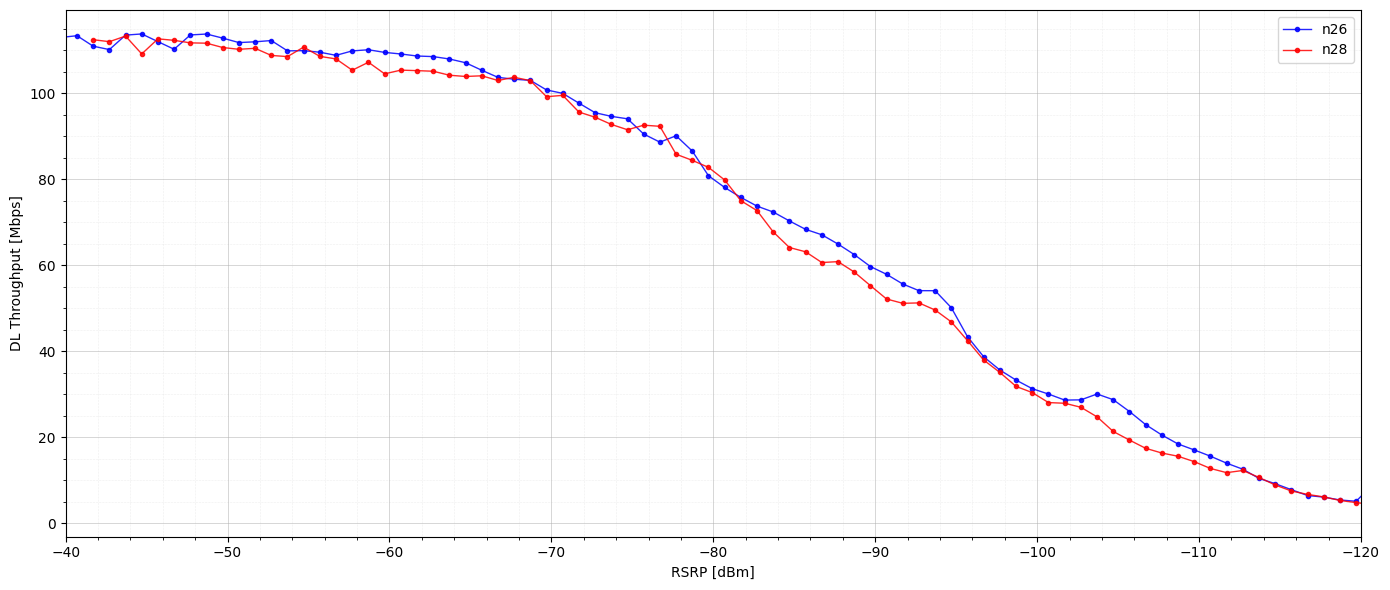

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange(df["RSRP"].min(), df["RSRP"].max() + 1, 1)
df["RSRP_bin"] = pd.cut(df["RSRP"], bins=bins, right=False)
df["RSRP_bin_center"] = df["RSRP_bin"].apply(lambda x: (x.left + x.right) / 2)

df_grouped = (
    df.groupby(["Band", "RSRP_bin_center"], observed=True)["DL_Tput"]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
for band, color in zip(["n26", "n28"], ["blue", "red"]):
    df_sub = df_grouped[df_grouped["Band"] == band]
    ax.plot(
        df_sub["RSRP_bin_center"], df_sub["DL_Tput"],
        marker="o", markersize=3, label=band, color=color, linewidth=1, alpha=0.85
    )
ax.set_xlim(-120, -40)
ax.set_xlabel("RSRP [dBm]")
ax.set_ylabel("DL Throughput [Mbps]")
ax.legend()

ax.grid(True, which='major', linestyle='-', linewidth=0.6, alpha=0.6)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, alpha=0.4)

ax.invert_xaxis()

plt.tight_layout()
plt.show()

In [ ]:
df_pair = _common.grid_kpi(df, grid_size=grid_size)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ----------------------------
# 거리 구간 정의 (200m step)
# ----------------------------
bins = [0, 200, 400, 600, 800, 1000, np.inf]
labels = [
    "0–200 m", "200–400 m", "400–600 m",
    "600–800 m", "800–1000 m", "1000 m+"
]
df_pair["distance_bin"] = pd.cut(df_pair["distance"], bins=bins, labels=labels, right=False)

# ----------------------------
# 색상 로직
# ----------------------------
source_order = labels
base_sources = [s for s in source_order if s not in ['clean']]
num_base = len(base_sources)

cmap = matplotlib.colormaps.get_cmap("tab20b")
base_colors = [cmap(i / 20) for i in np.linspace(4, 19, num=num_base)]

# ----------------------------
# 그래프 그리기
# ----------------------------
plt.figure(figsize=(15,7))
plt.title("Average DL Throughput vs RSRP (n28)", fontsize=13)
plt.xlabel("RSRP_n28 (dBm)")
plt.ylabel("Average DL_Tput_n28 (Mbps)")
plt.grid(True, linestyle="--", alpha=0.4)

# 거리 순서를 역순으로 (멀리 → 가까이)
for label, color in zip(reversed(base_sources), reversed(base_colors)):
    df_sub = df_pair[df_pair["distance_bin"] == label].copy()
    if df_sub.empty:
        continue

    # 1 dB 단위 binning
    df_sub.loc[:, "RSRP_bin"] = df_sub["RSRP_n28"].astype(int)

    # 평균 계산
    df_binned = (
        df_sub.groupby("RSRP_bin", observed=True)["DL_Tput_n28"]
              .mean()
              .reset_index()
              .sort_values("RSRP_bin")
    )

    plt.plot(
        df_binned["RSRP_bin"],
        df_binned["DL_Tput_n28"],
        label=label,
        color=color,
        linewidth=1,
        marker='o',
        markersize=3,
    )

# ----------------------------
# 축/범례/레이아웃 설정
# ----------------------------
plt.gca().invert_xaxis()
plt.xlim(-60, -120)
# plt.ylim(0, 70)


# ✅ 범례를 그래프 안쪽에, 역순으로 배치
handles, legend_labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1],
    legend_labels[::-1],
    title="Distance",
    fontsize=11,
    title_fontsize=11,
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="gray"
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ----------------------------
# uhd_max 구간 정의 (3 dB step)
# ----------------------------
uhd_min, uhd_max = -38, df_pair["uhd_max"].max()
uhd_bins = np.arange(uhd_min, np.ceil(uhd_max) + 3, 3)
uhd_labels = [f"{uhd_bins[i]}~{uhd_bins[i+1]} dB" for i in range(len(uhd_bins)-1)]

# -38 이하 제외 후 구간화
df_pair_filtered = df_pair[df_pair["uhd_max"] > -38].copy()
df_pair_filtered["uhd_bin"] = pd.cut(df_pair_filtered["uhd_max"], bins=uhd_bins, labels=uhd_labels, right=False)

# ----------------------------
# 색상 로직
# ----------------------------
source_order = uhd_labels
base_sources = [s for s in source_order if s not in ['clean']]
num_base = len(base_sources)

cmap = matplotlib.colormaps.get_cmap("tab20b")
base_colors = [cmap(i / 20) for i in np.linspace(4, 19, num=num_base)]

# ----------------------------
# 그래프 그리기
# ----------------------------
plt.figure(figsize=(15,7))
plt.title("Average DL Throughput vs RSRP (n28) by UHD_MAX bins", fontsize=13)
plt.xlabel("RSRP_n28 (dBm)")
plt.ylabel("Average DL_Tput_n28 (Mbps)")
plt.grid(True, linestyle="--", alpha=0.4)

# 구간 역순으로 (큰 UHD → 작은 UHD)
for label, color in zip(reversed(base_sources), reversed(base_colors)):
    df_sub = df_pair_filtered[df_pair_filtered["uhd_bin"] == label].copy()
    if df_sub.empty:
        continue

    # 1 dB 단위 binning
    df_sub.loc[:, "RSRP_bin"] = df_sub["RSRP_n28"].astype(int)

    # 평균 계산
    df_binned = (
        df_sub.groupby("RSRP_bin", observed=True)["DL_Tput_n28"]
              .mean()
              .reset_index()
              .sort_values("RSRP_bin")
    )

    plt.plot(
        df_binned["RSRP_bin"],
        df_binned["DL_Tput_n28"],
        label=label,
        color=color,
        linewidth=1,
        marker='o',
        markersize=3,
    )

# ----------------------------
# 축/범례/레이아웃 설정
# ----------------------------
plt.gca().invert_xaxis()
plt.xlim(-60, -120)
# plt.ylim(0,80)

handles, legend_labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles[::-1],
    legend_labels[::-1],
    title="UHD_MAX (dB)",
    fontsize=11,
    title_fontsize=11,
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="gray"
)

plt.tight_layout()
plt.show()